# Experiment 3: Layer-by-Layer Aesthetic Emergence

**Research Question**: How does the model build up aesthetic judgment across its layers? Is there a discrete "aesthetic computation" at a specific layer, or does it emerge gradually?

## Motivation
Experiment 2 revealed that **Layer 16** is a critical boundary — perfect classification, peak logit lens signal, and effective steering target. But we don't yet understand *how* the aesthetic judgment is constructed across layers 0→16.

## Method
1. **Aesthetic Sentence Dataset** — 80 sentences (40 beautiful, 40 plain/ugly) with ground-truth labels
2. **Linear Probes** — Train a logistic regression classifier at every layer on sentence activations → "emergence curve"
3. **Judgment Probes** — Wrap sentences in judgment prompts ("Is this beautiful?"), extract activations at the judgment position
4. **Logit Lens** — Track aesthetic token (beautiful/ugly/elegant/crude) trajectories for judgment prompts
5. **Attention Analysis** — Identify attention heads that specialize in processing aesthetic features
6. **Cross-comparison** — Overlay with Experiment 2's classification curve

## 1. Setup & Environment

In [1]:
import neuroscope
import numpy as np
import sys, os, time, json, warnings
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from scipy import stats

# --- Matplotlib font config ---
_cjk_font_dir = '/usr/share/fonts/opentype/noto/'
for _fp in fm.findSystemFonts([_cjk_font_dir]):
    fm.fontManager.addfont(_fp)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

sys.path.insert(0, '/workspace/Test_bench')
import utils

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'

warnings.filterwarnings('ignore')
print(f'NeuroScope {neuroscope.__version__}, CUDA: {neuroscope.cuda_available()}')

NeuroScope 1.2.3, CUDA: True


In [2]:
# --- Config ---
MODEL_PATH = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
OUTPUT_DIR = Path('/workspace/Data/aesthetic_emergence')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load Experiment 2 results for comparison
EXP2_DIR = Path('/workspace/Data/aesthetic_experiment')

NOTHINK_SUFFIX = '<think>\n\n</think>\n\n'
SEED = 42
np.random.seed(SEED)

print(f'Output: {OUTPUT_DIR}')

Output: /workspace/Data/aesthetic_emergence


## 2. Load Engine

**Important**: `disable_flash_attention=True` is required for attention pattern extraction.

In [3]:
engine = neuroscope.Engine(
    model_path=MODEL_PATH,
    n_ctx=4096,
    n_gpu_layers=-1,
    n_seq_max=1,
    seed=SEED,
    temperature=0.7,
    top_p=0.95,
    top_k=40,
    verbose=True,
    disable_flash_attention=True   # Required for attention extraction
)

info = engine.model_info
N_LAYERS = info.n_layers
N_EMBD = info.n_embd
N_HEADS = info.n_heads
N_VOCAB = info.n_vocab
print(f'Model: {info.name}')
print(f'Layers: {N_LAYERS} | Hidden: {N_EMBD} | Heads: {N_HEADS} | Vocab: {N_VOCAB}')

Model: Qwen3 8B Awq Compatible Instruct
Layers: 36 | Hidden: 4096 | Heads: 32 | Vocab: 151936
[CoreEngine] Loading model: /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 104678520
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 104678520
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 102225 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           genera

[CoreEngine] Preparing logit lens resources:
  - Tensor shape: [151936, 4096]
  - Tensor type: q6_K
  - Quantized weights (q6_K) dequantized to FP16
  - FP16 weights allocated on GPU: 1187 MB
  - Logit lens ready for all model types!
[CoreEngine] Model loaded: Qwen3 8B Awq Compatible Instruct
  Architecture: qwen (qwen3)
  Layers: 36, Hidden: 4096
  Heads: 32 Q, 8 KV (GQA)


sor: loading tensor blk.0.ffn_gate.weight
create_tensor: loading tensor blk.0.ffn_down.weight
create_tensor: loading tensor blk.0.ffn_up.weight
create_tensor: loading tensor blk.1.attn_norm.weight
create_tensor: loading tensor blk.1.attn_q.weight
create_tensor: loading tensor blk.1.attn_k.weight
create_tensor: loading tensor blk.1.attn_v.weight
create_tensor: loading tensor blk.1.attn_output.weight
create_tensor: loading tensor blk.1.attn_k_norm.weight
create_tensor: loading tensor blk.1.attn_q_norm.weight
create_tensor: loading tensor blk.1.ffn_norm.weight
create_tensor: loading tensor blk.1.ffn_gate.weight
create_tensor: loading tensor blk.1.ffn_down.weight
create_tensor: loading tensor blk.1.ffn_up.weight
create_tensor: loading tensor blk.2.attn_norm.weight
create_tensor: loading tensor blk.2.attn_q.weight
create_tensor: loading tensor blk.2.attn_k.weight
create_tensor: loading tensor blk.2.attn_v.weight
create_tensor: loading tensor blk.2.attn_output.weight
create_tensor: loading t

ache: layer   8: dev = CUDA0
llama_kv_cache: layer   9: dev = CUDA0
llama_kv_cache: layer  10: dev = CUDA0
llama_kv_cache: layer  11: dev = CUDA0
llama_kv_cache: layer  12: dev = CUDA0
llama_kv_cache: layer  13: dev = CUDA0
llama_kv_cache: layer  14: dev = CUDA0
llama_kv_cache: layer  15: dev = CUDA0
llama_kv_cache: layer  16: dev = CUDA0
llama_kv_cache: layer  17: dev = CUDA0
llama_kv_cache: layer  18: dev = CUDA0
llama_kv_cache: layer  19: dev = CUDA0
llama_kv_cache: layer  20: dev = CUDA0
llama_kv_cache: layer  21: dev = CUDA0
llama_kv_cache: layer  22: dev = CUDA0
llama_kv_cache: layer  23: dev = CUDA0
llama_kv_cache: layer  24: dev = CUDA0
llama_kv_cache: layer  25: dev = CUDA0
llama_kv_cache: layer  26: dev = CUDA0
llama_kv_cache: layer  27: dev = CUDA0
llama_kv_cache: layer  28: dev = CUDA0
llama_kv_cache: layer  29: dev = CUDA0
llama_kv_cache: layer  30: dev = CUDA0
llama_kv_cache: layer  31: dev = CUDA0
llama_kv_cache: layer  32: dev = CUDA0
llama_kv_cache: layer  33: dev = CU

## 3. Aesthetic Sentence Dataset

80 sentences rated for aesthetic quality:
- **40 Beautiful** — literary, poetic, sensory-rich with imagery and elegance
- **40 Plain/Ugly** — dry, factual, mundane, or describing unappealing things

Controlled for length (~10-25 words). Mixed domains (nature, art, music, daily life, architecture).

In [4]:
# ============================================================
# Aesthetic Sentence Dataset (ground-truth labeled)
# Label: 1 = beautiful, 0 = plain/ugly
# ============================================================

BEAUTIFUL_SENTENCES = [
    # Nature
    "The morning dew glistened on the spider's web like scattered diamonds.",
    "A cascade of cherry blossoms drifted through the still spring air.",
    "The sunset painted the clouds in shades of gold and violet.",
    "Moonlight rippled across the lake like liquid silver.",
    "The ancient oak stretched its gnarled branches toward the fading sky.",
    "Wildflowers swayed in the meadow, a tapestry of color under the summer sun.",
    "Frost etched delicate fern patterns across the windowpane at dawn.",
    "The waterfall thundered into the pool below, mist rising like breath.",
    # Art & Music
    "The cellist drew a melody so tender it made the silence ache.",
    "Vermeer's light fell across the girl's face like a whispered secret.",
    "The soprano's voice soared through the cathedral, pure as crystal.",
    "Each brushstroke on the canvas seemed to breathe with quiet life.",
    "The piano notes cascaded like rain on a still autumn pond.",
    "The marble sculpture captured a moment of impossible grace.",
    "A single violin sang through the empty concert hall at dusk.",
    "The fresco's colors glowed with a warmth that centuries could not dim.",
    # Architecture & Design
    "The cathedral's stained glass scattered rainbows across the stone floor.",
    "Slender arches rose in perfect symmetry, framing the courtyard garden.",
    "The spiral staircase ascended in an elegant helix of polished wood.",
    "Light poured through the oculus, illuminating the dome's golden mosaic.",
    "The bridge arched gracefully over the river, its reflection completing the circle.",
    "White columns stood in serene rows, their shadows long in the afternoon light.",
    "The glass pavilion seemed to float above the garden, weightless and luminous.",
    "Lanterns hung from the eaves, casting warm pools of amber on the snow.",
    # Literary & Emotional
    "Her laughter was the sound of sunlight breaking through winter clouds.",
    "The old letter, yellowed with time, still carried the scent of roses.",
    "Silence settled over the garden like a soft, warm blanket of snow.",
    "The child's eyes held the wonder of someone seeing the ocean for the first time.",
    "Time seemed to slow as the last leaf spiraled down from the maple.",
    "The dancers moved as one, a flowing river of silk and shadow.",
    "Words fell from her lips like petals from a windblown rose.",
    "The twilight hour wrapped the village in shades of lavender and pearl.",
    # Sensory & Gustatory
    "The tea released a fragrance of jasmine and mountain mist.",
    "Warm bread filled the kitchen with a scent both simple and divine.",
    "The chocolate melted on the tongue, rich and velvety as dark silk.",
    "Rain on hot stone released the earth's deep, intoxicating perfume.",
    "The wine held notes of blackberry, cedar, and a hint of autumn smoke.",
    "Honey dripped from the comb in slow, golden threads of sweetness.",
    "The spice market overflowed with saffron, cardamom, and cinnamon warmth.",
    "Fresh snow had a taste like cold starlight on the tongue.",
]

PLAIN_UGLY_SENTENCES = [
    # Mundane / Factual
    "The office building had twelve floors and a flat concrete roof.",
    "The spreadsheet contained rows of quarterly sales figures from last year.",
    "The parking lot was half empty with oil stains on the asphalt.",
    "The instruction manual listed the steps for assembling the shelf unit.",
    "The warehouse stored boxes of various sizes on metal shelving.",
    "The bus arrived three minutes late to the stop on Main Street.",
    "The fluorescent lights hummed steadily in the windowless break room.",
    "The report summarized the monthly expenditure across all departments.",
    # Ugly / Unpleasant
    "Garbage bags split open in the alley, spilling rotting food scraps.",
    "The stagnant ditch water was thick with algae and mosquito larvae.",
    "Rust had eaten through the metal railing, leaving jagged orange edges.",
    "The abandoned factory leaked oily water into the cracked parking lot.",
    "Mildew crept across the bathroom ceiling in patches of grey and black.",
    "The overflowing drain sent sewage seeping across the basement floor.",
    "Dead flies lined the windowsill of the vacant apartment.",
    "The landfill stretched to the horizon, a landscape of refuse and gulls.",
    # Dry / Technical
    "The database index was rebuilt after the scheduled maintenance window.",
    "The thermostat was set to twenty-two degrees Celsius year-round.",
    "The fire extinguisher inspection was due on the fifteenth of each month.",
    "The router firmware was updated to version three point four point one.",
    "The standard operating procedure required two signatures per form.",
    "The concrete mix ratio was one part cement to three parts aggregate.",
    "Annual inventory reconciliation was completed on the last business day.",
    "The cable tray ran along the ceiling from the server room to reception.",
    # Bland / Generic
    "The room had a table, four chairs, and a window facing the street.",
    "He walked to the store, bought milk, and walked back home.",
    "The meeting lasted one hour and covered three agenda items.",
    "The car was parked in the second row of the underground garage.",
    "The form required a name, date of birth, and mailing address.",
    "The vending machine dispensed a can of cola for one dollar fifty.",
    "The copy machine printed fifty pages in about four minutes.",
    "The elevator stopped on every floor during the morning rush.",
    # Unpleasant Sensory
    "The cafeteria food tasted of reheated cardboard and stale grease.",
    "The chemical smell from the factory made the whole block unpleasant.",
    "Lukewarm instant coffee sat in a styrofoam cup on the desk.",
    "The synthetic carpet gave off a sharp, acrid smell in the heat.",
    "The noise of the jackhammer rattled the windows for hours on end.",
    "The overcooked vegetables had turned to a grey, mushy paste.",
    "Stale cigarette smoke clung to the curtains and upholstery.",
    "The tap water had a faint metallic taste that never quite went away.",
]

assert len(BEAUTIFUL_SENTENCES) == 40
assert len(PLAIN_UGLY_SENTENCES) == 40

ALL_SENTENCES = BEAUTIFUL_SENTENCES + PLAIN_UGLY_SENTENCES
LABELS = np.array([1]*40 + [0]*40)  # 1=beautiful, 0=plain/ugly

print(f'Dataset: {len(BEAUTIFUL_SENTENCES)} beautiful + {len(PLAIN_UGLY_SENTENCES)} plain/ugly = {len(ALL_SENTENCES)} total')

Dataset: 40 beautiful + 40 plain/ugly = 80 total


## 4. Collect Activations

Two modes of collection:
1. **Content activations** — Forward the raw sentence (in chat template), extract last-token activations at every layer. For probing: "does the model know this sentence is beautiful just from reading it?"
2. **Judgment activations** — Forward a judgment prompt ("Is this sentence beautiful?"), extract activations at the last token before the model answers. For probing: "does the model's judgment representation contain the answer?"

In [5]:
def collect_activations(engine, sentences, mode='content'):
    """Collect all-layer activations for each sentence.
    
    mode='content':  Just forward the sentence itself
    mode='judgment': Wrap in judgment prompt template
    
    Returns: np.ndarray of shape (n_sentences, n_layers, n_embd)
    """
    all_acts = []
    for i, sent in enumerate(sentences):
        if mode == 'content':
            messages = [{'role': 'user', 'content': sent}]
        elif mode == 'judgment':
            messages = [{'role': 'user', 'content': 
                f'Read this sentence and decide: is it aesthetically beautiful, or plain/ugly? '
                f'Answer with just one word (beautiful or ugly).\n\n"{sent}"\n\nAnswer:'}]
        else:
            raise ValueError(f'Unknown mode: {mode}')
        
        templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX
        engine.reset()
        engine.forward(templated, add_special=True)
        acts = engine.get_all_activations()  # list of [n_embd] per layer
        all_acts.append(np.array(acts))      # (n_layers, n_embd)
    
    return np.array(all_acts)  # (n_sentences, n_layers, n_embd)

print('Collector ready.')

Collector ready.


In [6]:
print('--- Collecting content activations ---')
t0 = time.time()
acts_content = collect_activations(engine, ALL_SENTENCES, mode='content')
t1 = time.time()
print(f'Content activations: {acts_content.shape} in {t1-t0:.1f}s')

print('\n--- Collecting judgment activations ---')
acts_judgment = collect_activations(engine, ALL_SENTENCES, mode='judgment')
t2 = time.time()
print(f'Judgment activations: {acts_judgment.shape} in {t2-t1:.1f}s')

# Save
np.savez_compressed(OUTPUT_DIR / 'emergence_activations.npz',
    acts_content=acts_content,
    acts_judgment=acts_judgment,
    labels=LABELS)
print(f'\nSaved: {(OUTPUT_DIR / "emergence_activations.npz").stat().st_size / 1e6:.1f} MB')

--- Collecting content activations ---
Content activations: (80, 36, 4096) in 4.0s

--- Collecting judgment activations ---
Judgment activations: (80, 36, 4096) in 4.1s

Saved: 87.5 MB


## 5. Linear Probes — Emergence Curve

At every layer, train a logistic regression probe to predict aesthetic label from the activation vector. 5-fold cross-validation. This reveals **where** the model begins to linearly separate aesthetic from non-aesthetic content.

In [7]:
def probe_all_layers(activations, labels, n_splits=5):
    """Train a linear probe at each layer. Returns (n_layers, 4) array:
       columns = [auc_mean, auc_std, acc_mean, acc_std]
    """
    n_layers = activations.shape[1]
    results = np.zeros((n_layers, 4))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    for layer in range(n_layers):
        X = activations[:, layer, :]
        aucs, accs = [], []
        
        for train_idx, test_idx in skf.split(X, labels):
            clf = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)
            clf.fit(X[train_idx], labels[train_idx])
            
            pred_proba = clf.predict_proba(X[test_idx])[:, 1]
            pred_label = clf.predict(X[test_idx])
            
            aucs.append(roc_auc_score(labels[test_idx], pred_proba))
            accs.append(accuracy_score(labels[test_idx], pred_label))
        
        results[layer] = [np.mean(aucs), np.std(aucs), np.mean(accs), np.std(accs)]
    
    return results

print('Probing content activations...')
t0 = time.time()
probe_content = probe_all_layers(acts_content, LABELS)
print(f'  Done in {time.time()-t0:.1f}s')

print('Probing judgment activations...')
t0 = time.time()
probe_judgment = probe_all_layers(acts_judgment, LABELS)
print(f'  Done in {time.time()-t0:.1f}s')

# Print summary table
print(f'\n{"Layer":>5} | {"Content AUC":>12} | {"Judgment AUC":>12}')
print('-' * 40)
for layer in range(0, N_LAYERS, 4):
    print(f'{layer:>5} | {probe_content[layer,0]:.3f}±{probe_content[layer,1]:.3f} | '
          f'{probe_judgment[layer,0]:.3f}±{probe_judgment[layer,1]:.3f}')

Probing content activations...
  Done in 112.6s
Probing judgment activations...
  Done in 109.4s

Layer |  Content AUC | Judgment AUC
----------------------------------------
    0 | 0.919±0.082 | 0.844±0.127
    4 | 1.000±0.000 | 0.931±0.076
    8 | 1.000±0.000 | 0.963±0.032
   12 | 0.997±0.006 | 0.991±0.012
   16 | 0.997±0.006 | 0.997±0.006
   20 | 1.000±0.000 | 1.000±0.000
   24 | 1.000±0.000 | 1.000±0.000
   28 | 1.000±0.000 | 1.000±0.000
   32 | 1.000±0.000 | 1.000±0.000


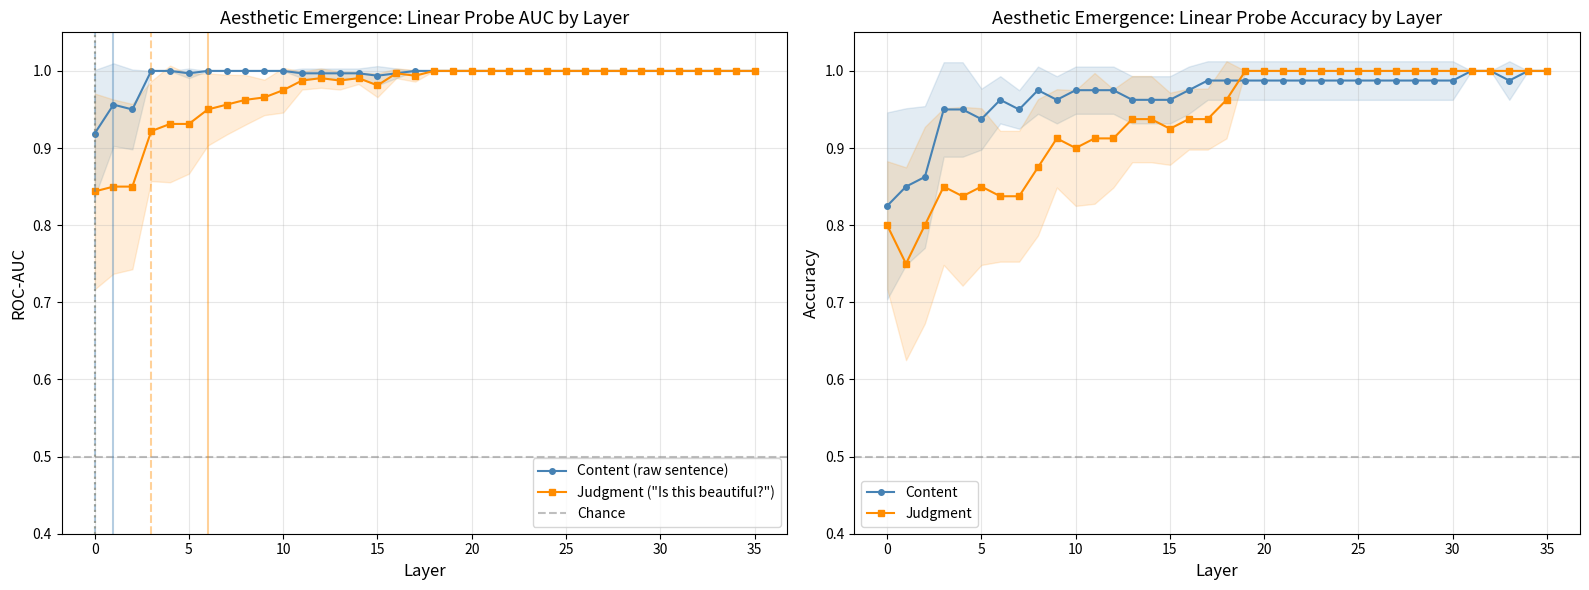

Content: AUC ≥ 0.75 at layer 0
Content: AUC ≥ 0.90 at layer 0
Content: AUC ≥ 0.95 at layer 1
Content: AUC ≥ 1.00 at layer 3
Judgment: AUC ≥ 0.75 at layer 0
Judgment: AUC ≥ 0.90 at layer 3
Judgment: AUC ≥ 0.95 at layer 6
Judgment: AUC ≥ 1.00 at layer 18


In [8]:
# --- Emergence Curve Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

layers = np.arange(N_LAYERS)

# AUC
ax = axes[0]
ax.plot(layers, probe_content[:, 0], 'o-', color='steelblue', label='Content (raw sentence)', markersize=4)
ax.fill_between(layers, probe_content[:, 0] - probe_content[:, 1], 
                probe_content[:, 0] + probe_content[:, 1], alpha=0.15, color='steelblue')
ax.plot(layers, probe_judgment[:, 0], 's-', color='darkorange', label='Judgment ("Is this beautiful?")', markersize=4)
ax.fill_between(layers, probe_judgment[:, 0] - probe_judgment[:, 1],
                probe_judgment[:, 0] + probe_judgment[:, 1], alpha=0.15, color='darkorange')
ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='Chance')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Aesthetic Emergence: Linear Probe AUC by Layer', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.3)

# Mark emergence thresholds
for threshold, ls in [(0.75, ':'), (0.90, '--'), (0.95, '-')]:
    for data, color, name in [(probe_content, 'steelblue', 'C'), (probe_judgment, 'darkorange', 'J')]:
        exceed = np.where(data[:, 0] >= threshold)[0]
        if len(exceed) > 0:
            first = exceed[0]
            ax.axvline(first, color=color, ls=ls, alpha=0.4)

# Accuracy
ax = axes[1]
ax.plot(layers, probe_content[:, 2], 'o-', color='steelblue', label='Content', markersize=4)
ax.fill_between(layers, probe_content[:, 2] - probe_content[:, 3],
                probe_content[:, 2] + probe_content[:, 3], alpha=0.15, color='steelblue')
ax.plot(layers, probe_judgment[:, 2], 's-', color='darkorange', label='Judgment', markersize=4)
ax.fill_between(layers, probe_judgment[:, 2] - probe_judgment[:, 3],
                probe_judgment[:, 2] + probe_judgment[:, 3], alpha=0.15, color='darkorange')
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Aesthetic Emergence: Linear Probe Accuracy by Layer', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'emergence_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Report emergence layers
for name, data in [('Content', probe_content), ('Judgment', probe_judgment)]:
    for th in [0.75, 0.90, 0.95, 1.00]:
        exceed = np.where(data[:, 0] >= th - 0.001)[0]
        layer_str = str(exceed[0]) if len(exceed) > 0 else 'never'
        print(f'{name}: AUC ≥ {th:.2f} at layer {layer_str}')

## 6. Layer-wise Emergence Gradient

Compute the **rate of change** of probe accuracy across layers — the "aesthetic gradient". Peaks indicate layers where the most aesthetic information is added.

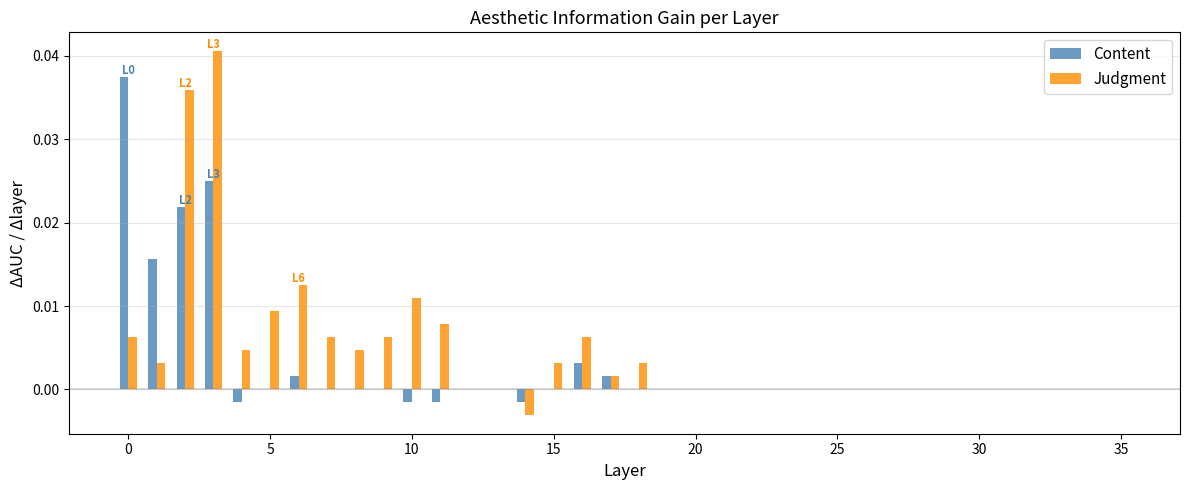

Peak aesthetic information gain layers:
  Content:  [0 3 2] (ΔAUC = [0.0375   0.025    0.021875])
  Judgment: [3 2 6] (ΔAUC = [0.040625  0.0359375 0.0125   ])


In [9]:
# Compute gradient (finite differences)
gradient_content = np.gradient(probe_content[:, 0])   # d(AUC)/d(layer)
gradient_judgment = np.gradient(probe_judgment[:, 0])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(layers - 0.15, gradient_content, width=0.3, color='steelblue', alpha=0.8, label='Content')
ax.bar(layers + 0.15, gradient_judgment, width=0.3, color='darkorange', alpha=0.8, label='Judgment')
ax.axhline(0, color='gray', ls='-', alpha=0.3)
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('ΔAUC / Δlayer', fontsize=12)
ax.set_title('Aesthetic Information Gain per Layer', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Annotate top-3 layers
for data, color, name in [(gradient_content, 'steelblue', 'C'), (gradient_judgment, 'darkorange', 'J')]:
    top3 = np.argsort(data)[-3:][::-1]
    for idx in top3:
        ax.annotate(f'L{idx}', xy=(idx, data[idx]), fontsize=8, ha='center',
                    color=color, fontweight='bold', va='bottom')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'emergence_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

# Report peak gradient layers
print('Peak aesthetic information gain layers:')
print(f'  Content:  {np.argsort(gradient_content)[-3:][::-1]} (ΔAUC = {gradient_content[np.argsort(gradient_content)[-3:][::-1]]})')
print(f'  Judgment: {np.argsort(gradient_judgment)[-3:][::-1]} (ΔAUC = {gradient_judgment[np.argsort(gradient_judgment)[-3:][::-1]]})')

## 7. Comparison with Experiment 2

Overlay the Exp 2 contrastive classification curve (aesthetic description prompts) with the Exp 3 probing curves (sentence comprehension + judgment prompts).

In [10]:
# Load Experiment 2 classification results
exp2_data = np.load(EXP2_DIR / 'aesthetic_analysis_results.npz', allow_pickle=True)

# Check what keys are available
print('Exp 2 keys:', list(exp2_data.keys()))
for k in exp2_data.keys():
    v = exp2_data[k]
    if hasattr(v, 'shape'):
        print(f'  {k}: shape={v.shape}, dtype={v.dtype}')
    else:
        print(f'  {k}: {type(v)}')

Exp 2 keys: ['aesthetic_direction', 'aesthetic_direction_norm', 'layer_aucs', 'layer_accs', 'best_cls_layer', 'explained_var_all', 'domain_sim_matrix', 'domains']
  aesthetic_direction: shape=(36, 4096), dtype=float32
  aesthetic_direction_norm: shape=(36, 4096), dtype=float32
  layer_aucs: shape=(36, 2), dtype=float64
  layer_accs: shape=(36, 2), dtype=float64
  best_cls_layer: shape=(), dtype=int64
  explained_var_all: shape=(36, 10), dtype=float32
  domain_sim_matrix: shape=(5, 5), dtype=float64
  domains: shape=(5,), dtype=<U9


Exp2 data overlaid.


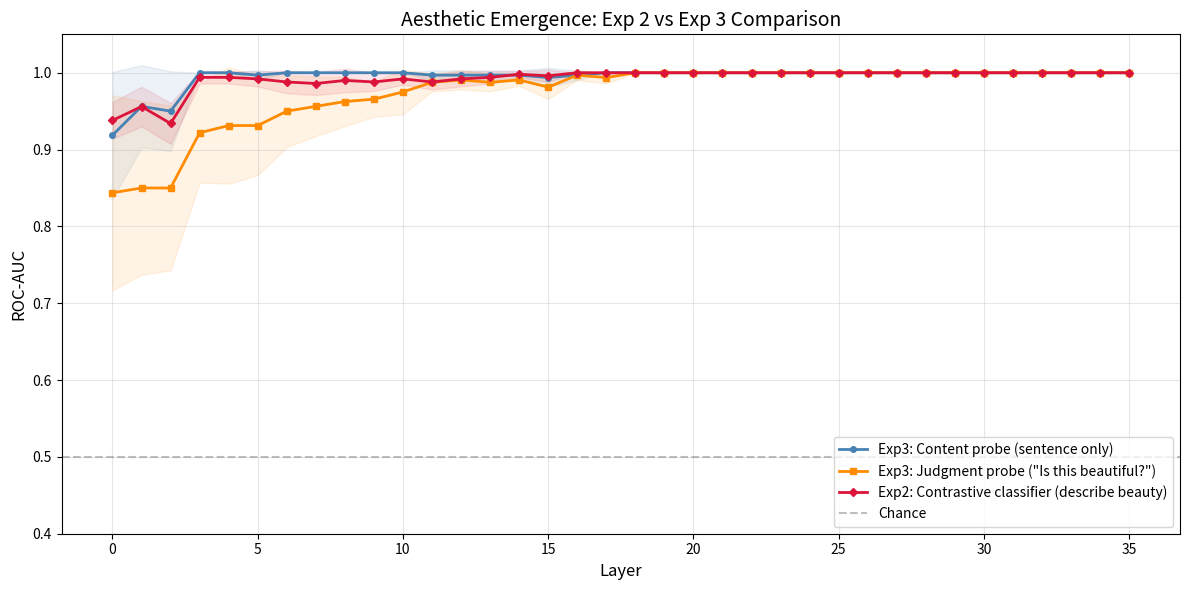

In [11]:
# Overlay comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

# Exp 3 Content probe
ax.plot(layers, probe_content[:, 0], 'o-', color='steelblue', label='Exp3: Content probe (sentence only)', markersize=4, linewidth=2)
ax.fill_between(layers, probe_content[:, 0] - probe_content[:, 1],
                probe_content[:, 0] + probe_content[:, 1], alpha=0.1, color='steelblue')

# Exp 3 Judgment probe
ax.plot(layers, probe_judgment[:, 0], 's-', color='darkorange', label='Exp3: Judgment probe ("Is this beautiful?")', markersize=4, linewidth=2)
ax.fill_between(layers, probe_judgment[:, 0] - probe_judgment[:, 1],
                probe_judgment[:, 0] + probe_judgment[:, 1], alpha=0.1, color='darkorange')

# Exp 2 classification (try to load it)
try:
    # Exp 2 stored layer_aucs as (n_layers, 2): [mean, std] from every-4-layer scan
    # Or it might have the full results — check keys
    if 'layer_aucs' in exp2_data:
        exp2_aucs = exp2_data['layer_aucs']
        if exp2_aucs.ndim == 2 and exp2_aucs.shape[0] == N_LAYERS:
            ax.plot(layers, exp2_aucs[:, 0], 'D-', color='crimson', label='Exp2: Contrastive classifier (describe beauty)', 
                    markersize=4, linewidth=2)
            ax.fill_between(layers, exp2_aucs[:, 0] - exp2_aucs[:, 1],
                            exp2_aucs[:, 0] + exp2_aucs[:, 1], alpha=0.1, color='crimson')
        else:
            # Might be sparse (every 4 layers)
            exp2_layers = np.arange(0, N_LAYERS, 4)
            if len(exp2_layers) == exp2_aucs.shape[0]:
                ax.plot(exp2_layers, exp2_aucs[:, 0], 'D-', color='crimson', 
                        label='Exp2: Contrastive classifier', markersize=5, linewidth=2)
    print('Exp2 data overlaid.')
except Exception as e:
    print(f'Could not overlay Exp2: {e}')

ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='Chance')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('Aesthetic Emergence: Exp 2 vs Exp 3 Comparison', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'emergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Logit Lens for Aesthetic Judgment Prompts

For judgment prompts, track logical predicate tokens ("beautiful", "ugly", "yes", "no") across layers. At which layer does the model "decide" its answer?

In [13]:
# Use HuggingFace tokenizer to get accurate token IDs
from transformers import AutoTokenizer
import os
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'

tokenizer = AutoTokenizer.from_pretrained('/workspace/Model/Qwen3-8B')

# Find single-token aesthetic and anti-aesthetic words
candidates_pos = ['beautiful', 'Beautiful', 'beauty', 'elegant', 'lovely', 'pretty',
                  'gorgeous', 'stunning', 'sublime', 'magnificent', 'wonderful',
                  'aesthetic', 'harmonious', 'delightful', 'charming', 'graceful']
candidates_neg = ['ugly', 'Ugly', 'plain', 'Plain', 'bland', 'dull', 'boring',
                  'hideous', 'crude', 'mundane', 'awful', 'terrible', 'mediocre',
                  'ordinary', 'unremarkable', 'unattractive']

def check_single_token(tokenizer, word):
    """Check if word is a single token. Returns (True, token_id) or (False, first_token_id)."""
    ids = tokenizer.encode(word, add_special_tokens=False)
    return len(ids) == 1, ids[0]

print('=== Aesthetic (positive) tokens ===')
aesthetic_tids = {}
for w in candidates_pos:
    is_single, tid = check_single_token(tokenizer, w)
    decoded = tokenizer.decode([tid])
    marker = '✓' if is_single else '✗'
    if is_single:
        aesthetic_tids[w] = tid
    print(f'  {marker} {w:15s} → token {tid:6d} (decodes: "{decoded}") {"SINGLE" if is_single else f"multi({len(tokenizer.encode(w, add_special_tokens=False))} tokens)"}')

print(f'\n=== Anti-aesthetic (negative) tokens ===')
anti_tids = {}
for w in candidates_neg:
    is_single, tid = check_single_token(tokenizer, w)
    decoded = tokenizer.decode([tid])
    marker = '✓' if is_single else '✗'
    if is_single:
        anti_tids[w] = tid
    print(f'  {marker} {w:15s} → token {tid:6d} (decodes: "{decoded}") {"SINGLE" if is_single else f"multi({len(tokenizer.encode(w, add_special_tokens=False))} tokens)"}')

print(f'\nUsing {len(aesthetic_tids)} aesthetic + {len(anti_tids)} anti-aesthetic single-token words')
print(f'Aesthetic: {list(aesthetic_tids.keys())}')
print(f'Anti-aesthetic: {list(anti_tids.keys())}')

=== Aesthetic (positive) tokens ===
  ✓ beautiful       → token  86944 (decodes: "beautiful") SINGLE
  ✓ Beautiful       → token  46518 (decodes: "Beautiful") SINGLE
  ✗ beauty          → token   1371 (decodes: "be") multi(2 tokens)
  ✗ elegant         → token     68 (decodes: "e") multi(2 tokens)
  ✗ lovely          → token    385 (decodes: "lo") multi(2 tokens)
  ✓ pretty          → token  32955 (decodes: "pretty") SINGLE
  ✗ gorgeous        → token   5628 (decodes: "gor") multi(3 tokens)
  ✗ stunning        → token    267 (decodes: "st") multi(2 tokens)
  ✗ sublime         → token   1966 (decodes: "sub") multi(2 tokens)
  ✗ magnificent     → token     76 (decodes: "m") multi(3 tokens)
  ✗ wonderful       → token     86 (decodes: "w") multi(3 tokens)
  ✗ aesthetic       → token     64 (decodes: "a") multi(2 tokens)
  ✗ harmonious      → token  12982 (decodes: "har") multi(3 tokens)
  ✗ delightful      → token   9588 (decodes: "del") multi(3 tokens)
  ✗ charming        → token   1762 

In [14]:
# Collect logit lens for judgment prompts: 10 beautiful + 10 ugly
N_SAMPLE = 10

def collect_logit_lens_judgment(engine, sentences, n_sample):
    """Collect logit_lens_all for judgment prompts.
    Returns list of (n_layers, n_vocab) arrays."""
    results = []
    for i, sent in enumerate(sentences[:n_sample]):
        messages = [{'role': 'user', 'content': 
            f'Read this sentence and decide: is it aesthetically beautiful, or plain/ugly? '
            f'Answer with just one word (beautiful or ugly).\n\n"{sent}"\n\nAnswer:'}]
        templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX
        engine.reset()
        engine.forward(templated, add_special=True)
        logit_all = engine.logit_lens_all()  # (n_layers, n_vocab)
        results.append(logit_all)
        if (i + 1) % 5 == 0:
            print(f'  [{i+1}/{n_sample}]')
    return results

print('Collecting logit lens for beautiful sentences...')
t0 = time.time()
logit_beautiful = collect_logit_lens_judgment(engine, BEAUTIFUL_SENTENCES, N_SAMPLE)
print(f'  Done: {len(logit_beautiful)} samples, shape: {logit_beautiful[0].shape}')

print('Collecting logit lens for ugly sentences...')
logit_ugly = collect_logit_lens_judgment(engine, PLAIN_UGLY_SENTENCES, N_SAMPLE)
t1 = time.time()
print(f'  Done: {len(logit_ugly)} samples, shape: {logit_ugly[0].shape}')
print(f'  Total time: {t1-t0:.1f}s')

  [5/10]
  [10/10]
  Done: 10 samples, shape: (36, 151936)
  [5/10]
  [10/10]
  Done: 10 samples, shape: (36, 151936)
  Total time: 5.2s


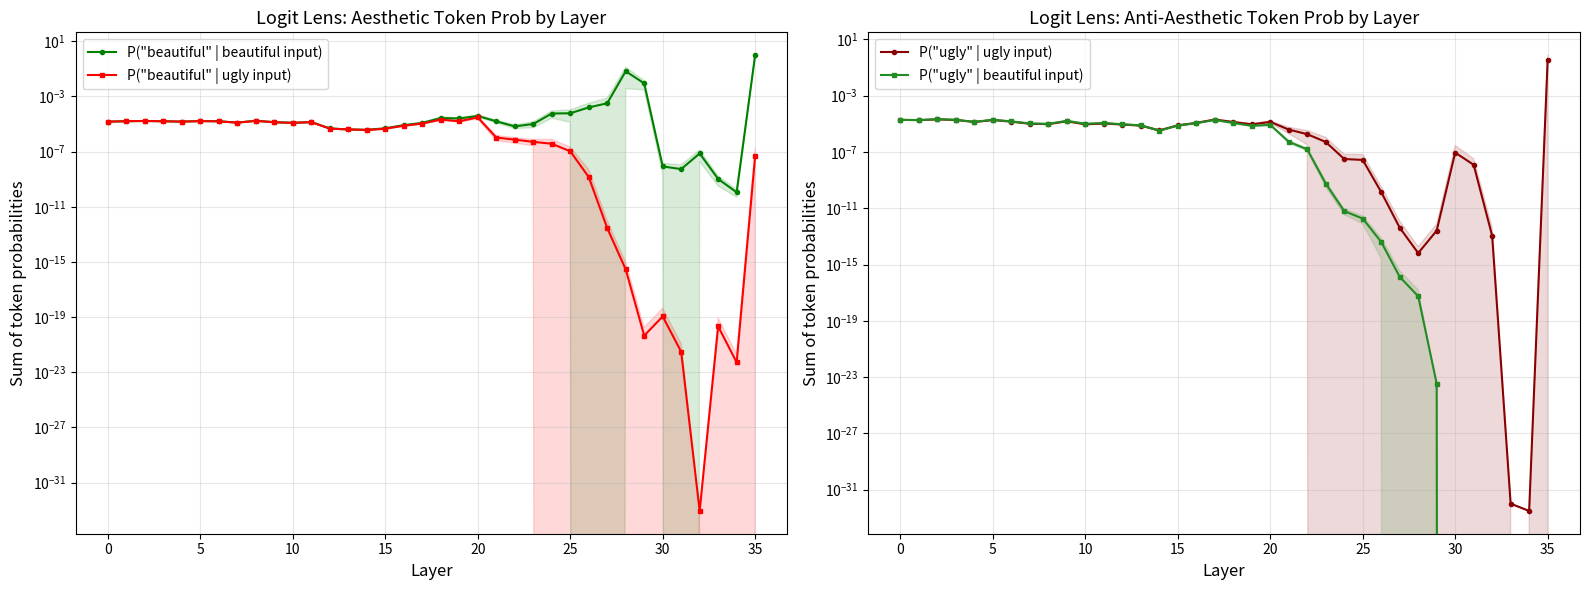

Beautiful diverges (aesthetic > 2× anti-aesthetic) at layer: 18
Ugly diverges (anti-aesthetic > 2× aesthetic) at layer: 21


In [15]:
# Convert logits to probabilities and track aesthetic vs anti-aesthetic
from scipy.special import softmax as scipy_softmax

def compute_token_probs(logit_lens_list, token_ids):
    """For each sample's logit lens, compute softmax and extract target token probs.
    Returns: (n_samples, n_layers) - sum of probabilities for the target tokens."""
    results = []
    for logits in logit_lens_list:  # (n_layers, n_vocab)
        probs = scipy_softmax(logits, axis=1)  # (n_layers, n_vocab)
        token_prob = sum(probs[:, tid] for tid in token_ids.values())
        results.append(token_prob)
    return np.array(results)  # (n_samples, n_layers)

# Prob of aesthetic tokens given beautiful input
p_aes_given_beautiful = compute_token_probs(logit_beautiful, aesthetic_tids)   # (10, 36)
p_anti_given_beautiful = compute_token_probs(logit_beautiful, anti_tids)       # (10, 36)

# Prob of aesthetic tokens given ugly input
p_aes_given_ugly = compute_token_probs(logit_ugly, aesthetic_tids)             # (10, 36)
p_anti_given_ugly = compute_token_probs(logit_ugly, anti_tids)                 # (10, 36)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(layers, p_aes_given_beautiful.mean(0), 'o-', color='green', label='P("beautiful" | beautiful input)', markersize=3)
ax.fill_between(layers, p_aes_given_beautiful.mean(0) - p_aes_given_beautiful.std(0),
                p_aes_given_beautiful.mean(0) + p_aes_given_beautiful.std(0), alpha=0.15, color='green')
ax.plot(layers, p_aes_given_ugly.mean(0), 's-', color='red', label='P("beautiful" | ugly input)', markersize=3)
ax.fill_between(layers, p_aes_given_ugly.mean(0) - p_aes_given_ugly.std(0),
                p_aes_given_ugly.mean(0) + p_aes_given_ugly.std(0), alpha=0.15, color='red')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Sum of token probabilities', fontsize=12)
ax.set_title('Logit Lens: Aesthetic Token Prob by Layer', fontsize=13)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(layers, p_anti_given_ugly.mean(0), 'o-', color='darkred', label='P("ugly" | ugly input)', markersize=3)
ax.fill_between(layers, p_anti_given_ugly.mean(0) - p_anti_given_ugly.std(0),
                p_anti_given_ugly.mean(0) + p_anti_given_ugly.std(0), alpha=0.15, color='darkred')
ax.plot(layers, p_anti_given_beautiful.mean(0), 's-', color='forestgreen', label='P("ugly" | beautiful input)', markersize=3)
ax.fill_between(layers, p_anti_given_beautiful.mean(0) - p_anti_given_beautiful.std(0),
                p_anti_given_beautiful.mean(0) + p_anti_given_beautiful.std(0), alpha=0.15, color='forestgreen')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Sum of token probabilities', fontsize=12)
ax.set_title('Logit Lens: Anti-Aesthetic Token Prob by Layer', fontsize=13)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'logit_lens_judgment.png', dpi=150, bbox_inches='tight')
plt.show()

# Divergence layer: where the curves cross
ratio_beautiful = p_aes_given_beautiful.mean(0) / (p_anti_given_beautiful.mean(0) + 1e-40)
ratio_ugly = p_anti_given_ugly.mean(0) / (p_aes_given_ugly.mean(0) + 1e-40)
diverge_b = np.where(ratio_beautiful > 2.0)[0]
diverge_u = np.where(ratio_ugly > 2.0)[0]
print(f'Beautiful diverges (aesthetic > 2× anti-aesthetic) at layer: {diverge_b[0] if len(diverge_b) > 0 else "never"}')
print(f'Ugly diverges (anti-aesthetic > 2× aesthetic) at layer: {diverge_u[0] if len(diverge_u) > 0 else "never"}')

## 9. Attention Pattern Analysis

For each layer, collect attention patterns for beautiful vs. ugly judgment prompts. Identify heads that **differentially attend** to aesthetic content words.

In [16]:
# Collect attention patterns for a smaller sample (attention is memory-heavy)
N_ATTN_SAMPLE = 5  # 5 beautiful + 5 ugly
ANALYSIS_LAYERS = [0, 4, 8, 12, 16, 20, 24, 28, 32, 35]  # 10 key layers

def collect_attention_patterns(engine, sentences, analysis_layers, n_sample):
    """Collect attention patterns at key layers for judgment prompts.
    Returns: dict[(layer, sample_idx)] -> (n_heads, seq_len, kv_len)
    """
    patterns = {}
    for i, sent in enumerate(sentences[:n_sample]):
        messages = [{'role': 'user', 'content': 
            f'Read this sentence and decide: is it aesthetically beautiful, or plain/ugly? '
            f'Answer with just one word (beautiful or ugly).\n\n"{sent}"\n\nAnswer:'}]
        templated = engine.apply_chat_template(messages) + NOTHINK_SUFFIX
        engine.reset()
        engine.forward(templated, add_special=True)
        
        for layer in analysis_layers:
            attn = engine.get_attention(layer)  # (n_heads, seq_len, kv_len)
            # Store only the last-token attention (the "judgment" token)
            # Shape: (n_heads, kv_len) — where does the judgment token attend?
            patterns[(layer, i)] = attn[:, -1, :]  # last token's attention over all positions
    
    return patterns

print(f'Collecting attention for {N_ATTN_SAMPLE} beautiful sentences...')
t0 = time.time()
attn_beautiful = collect_attention_patterns(engine, BEAUTIFUL_SENTENCES, ANALYSIS_LAYERS, N_ATTN_SAMPLE)
print(f'  Done in {time.time()-t0:.1f}s')

print(f'Collecting attention for {N_ATTN_SAMPLE} ugly sentences...')
t0 = time.time()
attn_ugly = collect_attention_patterns(engine, PLAIN_UGLY_SENTENCES, ANALYSIS_LAYERS, N_ATTN_SAMPLE)
print(f'  Done in {time.time()-t0:.1f}s')

# Report shapes
sample_key = (ANALYSIS_LAYERS[0], 0)
print(f'\nAttention pattern shape: {attn_beautiful[sample_key].shape}  (n_heads, kv_len)')

  Done in 0.3s
  Done in 0.3s

Attention pattern shape: (32, 256)  (n_heads, kv_len)


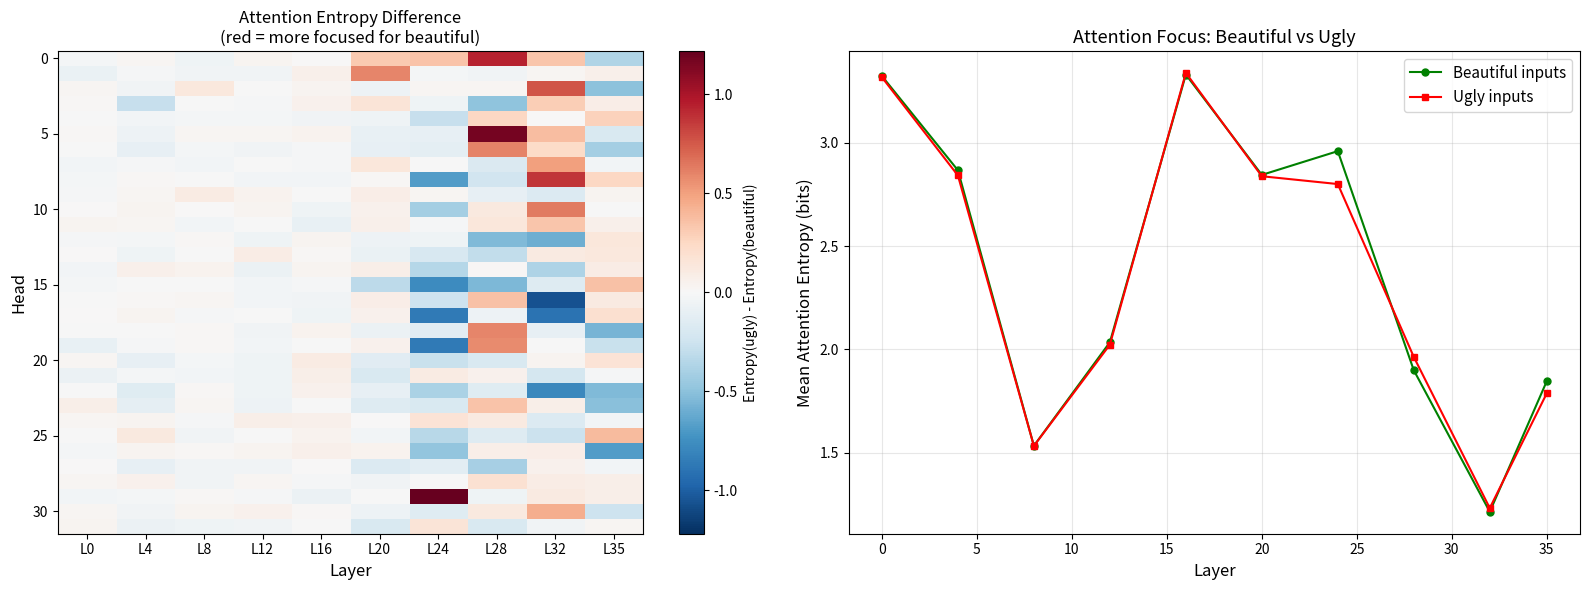

Top 5 heads with largest entropy difference (most aesthetic-sensitive):
  Layer 24, Head 29: ΔEntropy = 1.220
  Layer 28, Head 5: ΔEntropy = 1.170
  Layer 32, Head 16: ΔEntropy = -1.067
  Layer 28, Head 0: ΔEntropy = 0.940
  Layer 32, Head 17: ΔEntropy = -0.900


In [17]:
# --- Attention Entropy Analysis ---
# For each head at each layer, compute the entropy of the attention distribution.
# Lower entropy = more focused attention. Compare beautiful vs ugly.

def attention_entropy(attn_vector):
    """Compute Shannon entropy of an attention distribution."""
    p = attn_vector + 1e-10
    return -np.sum(p * np.log2(p))

# Compute per-head entropy for each condition
entropy_beautiful = np.zeros((len(ANALYSIS_LAYERS), N_HEADS))
entropy_ugly = np.zeros((len(ANALYSIS_LAYERS), N_HEADS))

for li, layer in enumerate(ANALYSIS_LAYERS):
    for head in range(N_HEADS):
        ent_b = np.mean([attention_entropy(attn_beautiful[(layer, i)][head]) for i in range(N_ATTN_SAMPLE)])
        ent_u = np.mean([attention_entropy(attn_ugly[(layer, i)][head]) for i in range(N_ATTN_SAMPLE)])
        entropy_beautiful[li, head] = ent_b
        entropy_ugly[li, head] = ent_u

# Entropy difference: positive = more focused on beautiful, negative = more focused on ugly
entropy_diff = entropy_ugly - entropy_beautiful  # positive = more focused for beautiful inputs

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of entropy difference
ax = axes[0]
im = ax.imshow(entropy_diff.T, aspect='auto', cmap='RdBu_r', 
               vmin=-np.abs(entropy_diff).max(), vmax=np.abs(entropy_diff).max())
ax.set_xticks(range(len(ANALYSIS_LAYERS)))
ax.set_xticklabels([f'L{l}' for l in ANALYSIS_LAYERS])
ax.set_ylabel('Head', fontsize=12)
ax.set_xlabel('Layer', fontsize=12)
ax.set_title('Attention Entropy Difference\n(red = more focused for beautiful)', fontsize=12)
plt.colorbar(im, ax=ax, label='Entropy(ugly) - Entropy(beautiful)')

# Mean entropy across heads per layer
ax = axes[1]
ax.plot(ANALYSIS_LAYERS, entropy_beautiful.mean(axis=1), 'o-', color='green', label='Beautiful inputs', markersize=5)
ax.plot(ANALYSIS_LAYERS, entropy_ugly.mean(axis=1), 's-', color='red', label='Ugly inputs', markersize=5)
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Mean Attention Entropy (bits)', fontsize=12)
ax.set_title('Attention Focus: Beautiful vs Ugly', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'attention_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most differential heads
print('Top 5 heads with largest entropy difference (most aesthetic-sensitive):')
flat_diff = entropy_diff.flatten()
top_indices = np.argsort(np.abs(flat_diff))[-5:][::-1]
for idx in top_indices:
    li, head = divmod(idx, N_HEADS)
    layer = ANALYSIS_LAYERS[li]
    print(f'  Layer {layer}, Head {head}: ΔEntropy = {entropy_diff[li, head]:.3f}')

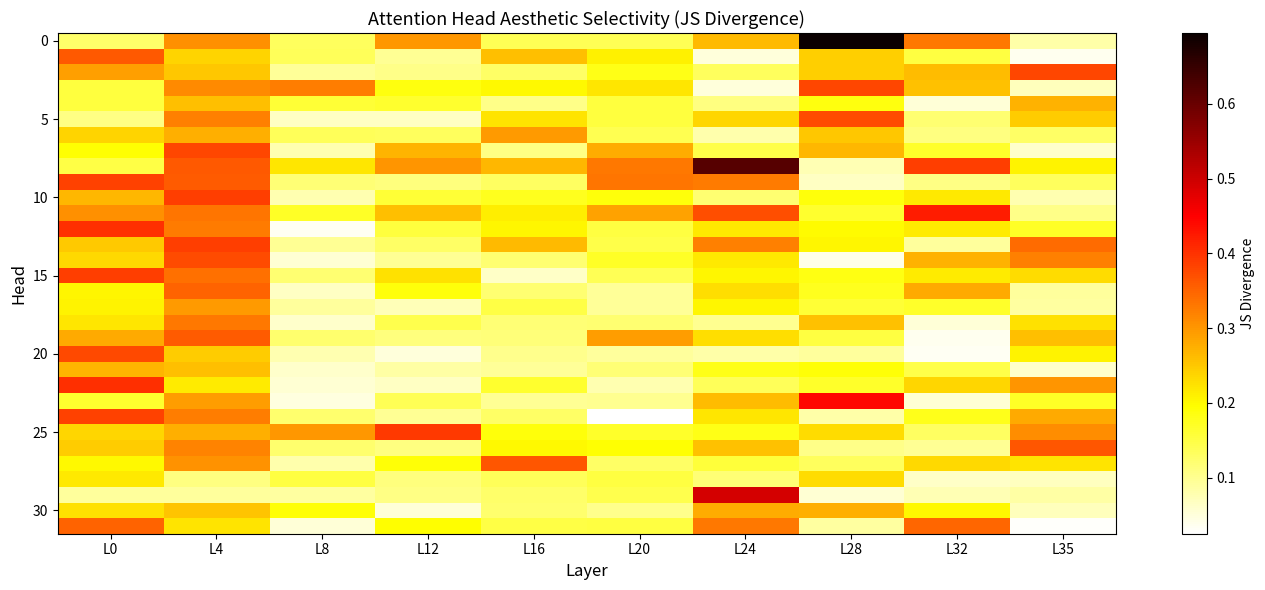


Top 10 most aesthetic-selective attention heads (highest JS divergence):
  Layer 28, Head  0: JS = 0.6948
  Layer 24, Head  8: JS = 0.6169
  Layer 24, Head 29: JS = 0.4910
  Layer 28, Head 23: JS = 0.4410
  Layer 32, Head 11: JS = 0.4219
  Layer  0, Head 22: JS = 0.4024
  Layer  0, Head 12: JS = 0.4023
  Layer 12, Head 25: JS = 0.3920
  Layer  0, Head 15: JS = 0.3882
  Layer  4, Head 10: JS = 0.3881

Mean JS divergence per layer:
  Layer  0: 0.2524 (max head: 22, JS=0.4024)
  Layer  4: 0.2956 (max head: 10, JS=0.3881)
  Layer  8: 0.1160 (max head: 3, JS=0.3235)
  Layer 12: 0.1524 (max head: 25, JS=0.3920)
  Layer 16: 0.1649 (max head: 27, JS=0.3649)
  Layer 20: 0.1648 (max head: 9, JS=0.3317)
  Layer 24: 0.2164 (max head: 8, JS=0.6169)
  Layer 28: 0.2062 (max head: 0, JS=0.6948)
  Layer 32: 0.1784 (max head: 11, JS=0.4219)
  Layer 35: 0.1781 (max head: 2, JS=0.3800)


In [18]:
# --- Attention Head Aesthetic Selectivity ---
# Compute attention divergence (KL or JS divergence) between beautiful and ugly conditions per head.
# Heads with high divergence = "aesthetic heads" that attend differently based on content aesthetics.

from scipy.spatial.distance import jensenshannon

# For each head at each analyzed layer, compute JS divergence
# between the mean attention pattern for beautiful vs ugly inputs
js_divergence = np.zeros((len(ANALYSIS_LAYERS), N_HEADS))

for li, layer in enumerate(ANALYSIS_LAYERS):
    for head in range(N_HEADS):
        # Mean attention distribution for this head across samples
        # Note: sequences may have different lengths, so we only compare attention over shared positions
        # For simplicity, use the first sample's length as reference
        
        # Stack attention patterns — they may have different kv_len due to different prompt lengths
        # Use the minimum kv_len across all samples
        min_kv_b = min(attn_beautiful[(layer, i)].shape[1] for i in range(N_ATTN_SAMPLE))
        min_kv_u = min(attn_ugly[(layer, i)].shape[1] for i in range(N_ATTN_SAMPLE))
        min_kv = min(min_kv_b, min_kv_u)
        
        mean_attn_b = np.mean([attn_beautiful[(layer, i)][head, :min_kv] for i in range(N_ATTN_SAMPLE)], axis=0)
        mean_attn_u = np.mean([attn_ugly[(layer, i)][head, :min_kv] for i in range(N_ATTN_SAMPLE)], axis=0)
        
        # Normalize to sum to 1
        mean_attn_b = mean_attn_b / (mean_attn_b.sum() + 1e-10)
        mean_attn_u = mean_attn_u / (mean_attn_u.sum() + 1e-10)
        
        js_divergence[li, head] = jensenshannon(mean_attn_b, mean_attn_u)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(js_divergence.T, aspect='auto', cmap='hot_r')
ax.set_xticks(range(len(ANALYSIS_LAYERS)))
ax.set_xticklabels([f'L{l}' for l in ANALYSIS_LAYERS])
ax.set_ylabel('Head', fontsize=12)
ax.set_xlabel('Layer', fontsize=12)
ax.set_title('Attention Head Aesthetic Selectivity (JS Divergence)', fontsize=13)
plt.colorbar(im, ax=ax, label='JS Divergence')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'attention_aesthetic_selectivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Report top aesthetic heads
print('\nTop 10 most aesthetic-selective attention heads (highest JS divergence):')
flat_js = js_divergence.flatten()
top_js = np.argsort(flat_js)[-10:][::-1]
for idx in top_js:
    li, head = divmod(idx, N_HEADS)
    layer = ANALYSIS_LAYERS[li]
    print(f'  Layer {layer:>2}, Head {head:>2}: JS = {js_divergence[li, head]:.4f}')

# Mean JS per layer
print('\nMean JS divergence per layer:')
for li, layer in enumerate(ANALYSIS_LAYERS):
    print(f'  Layer {layer:>2}: {js_divergence[li].mean():.4f} (max head: {js_divergence[li].argmax()}, JS={js_divergence[li].max():.4f})')

## 10. Detailed Attention Visualization for Top Aesthetic Heads

Visualize the actual attention patterns for the most aesthetic-selective heads — where do they "look" when processing beautiful vs. ugly sentences?

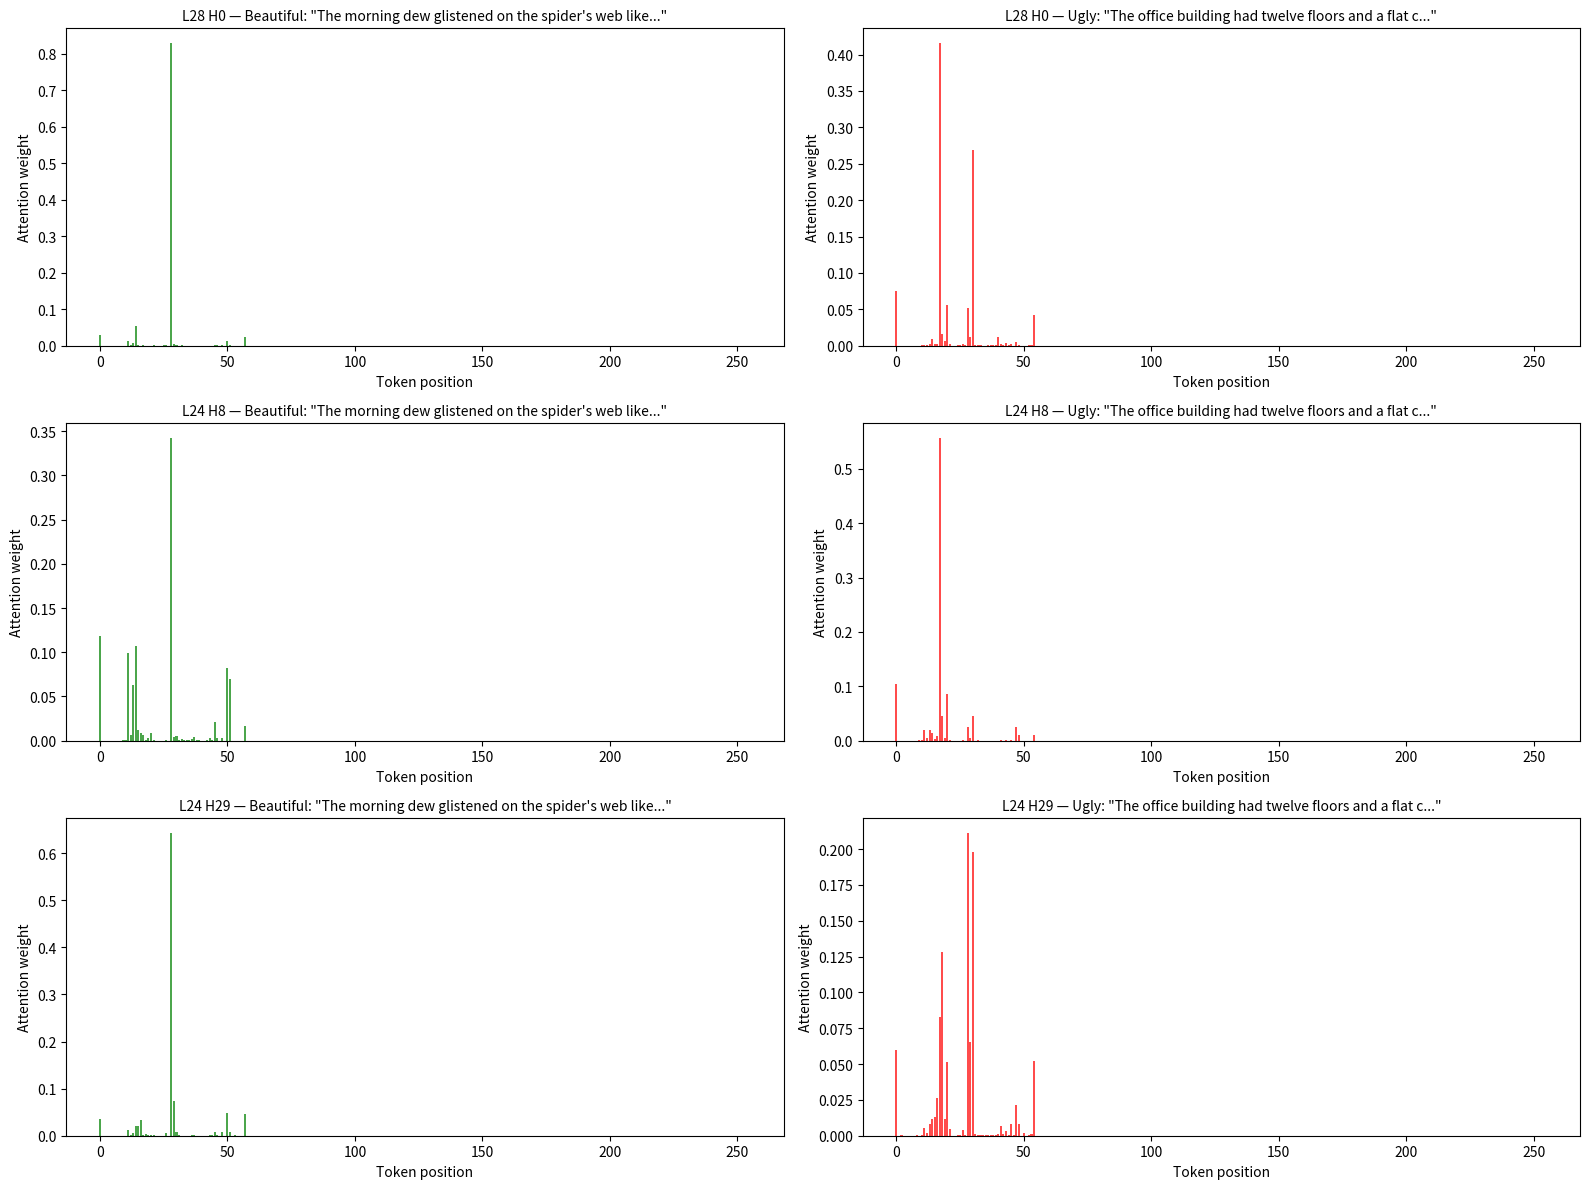

In [19]:
# Pick top-3 aesthetic heads for detailed visualization
top3_heads = []
flat_js = js_divergence.flatten()
for idx in np.argsort(flat_js)[-3:][::-1]:
    li, head = divmod(idx, N_HEADS)
    layer = ANALYSIS_LAYERS[li]
    top3_heads.append((layer, head, li))

# For each top head, show attention comparison for 1 beautiful vs 1 ugly sentence
fig, axes = plt.subplots(len(top3_heads), 2, figsize=(16, 4*len(top3_heads)))

for row, (layer, head, li) in enumerate(top3_heads):
    # Beautiful sentence (first sample)
    attn_b = attn_beautiful[(layer, 0)][head]  # (kv_len,)
    attn_u = attn_ugly[(layer, 0)][head]        # (kv_len,)
    
    ax = axes[row, 0] if len(top3_heads) > 1 else axes[0]
    ax.bar(range(len(attn_b)), attn_b, color='green', alpha=0.7)
    ax.set_title(f'L{layer} H{head} — Beautiful: "{BEAUTIFUL_SENTENCES[0][:50]}..."', fontsize=10)
    ax.set_xlabel('Token position')
    ax.set_ylabel('Attention weight')
    
    ax = axes[row, 1] if len(top3_heads) > 1 else axes[1]
    ax.bar(range(len(attn_u)), attn_u, color='red', alpha=0.7)
    ax.set_title(f'L{layer} H{head} — Ugly: "{PLAIN_UGLY_SENTENCES[0][:50]}..."', fontsize=10)
    ax.set_xlabel('Token position')
    ax.set_ylabel('Attention weight')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_aesthetic_heads_attention.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Activation Trajectory Visualization

Project activations onto the 2D PCA space at each layer to show how the model's representation of beautiful vs. ugly sentences **evolves** through the network.

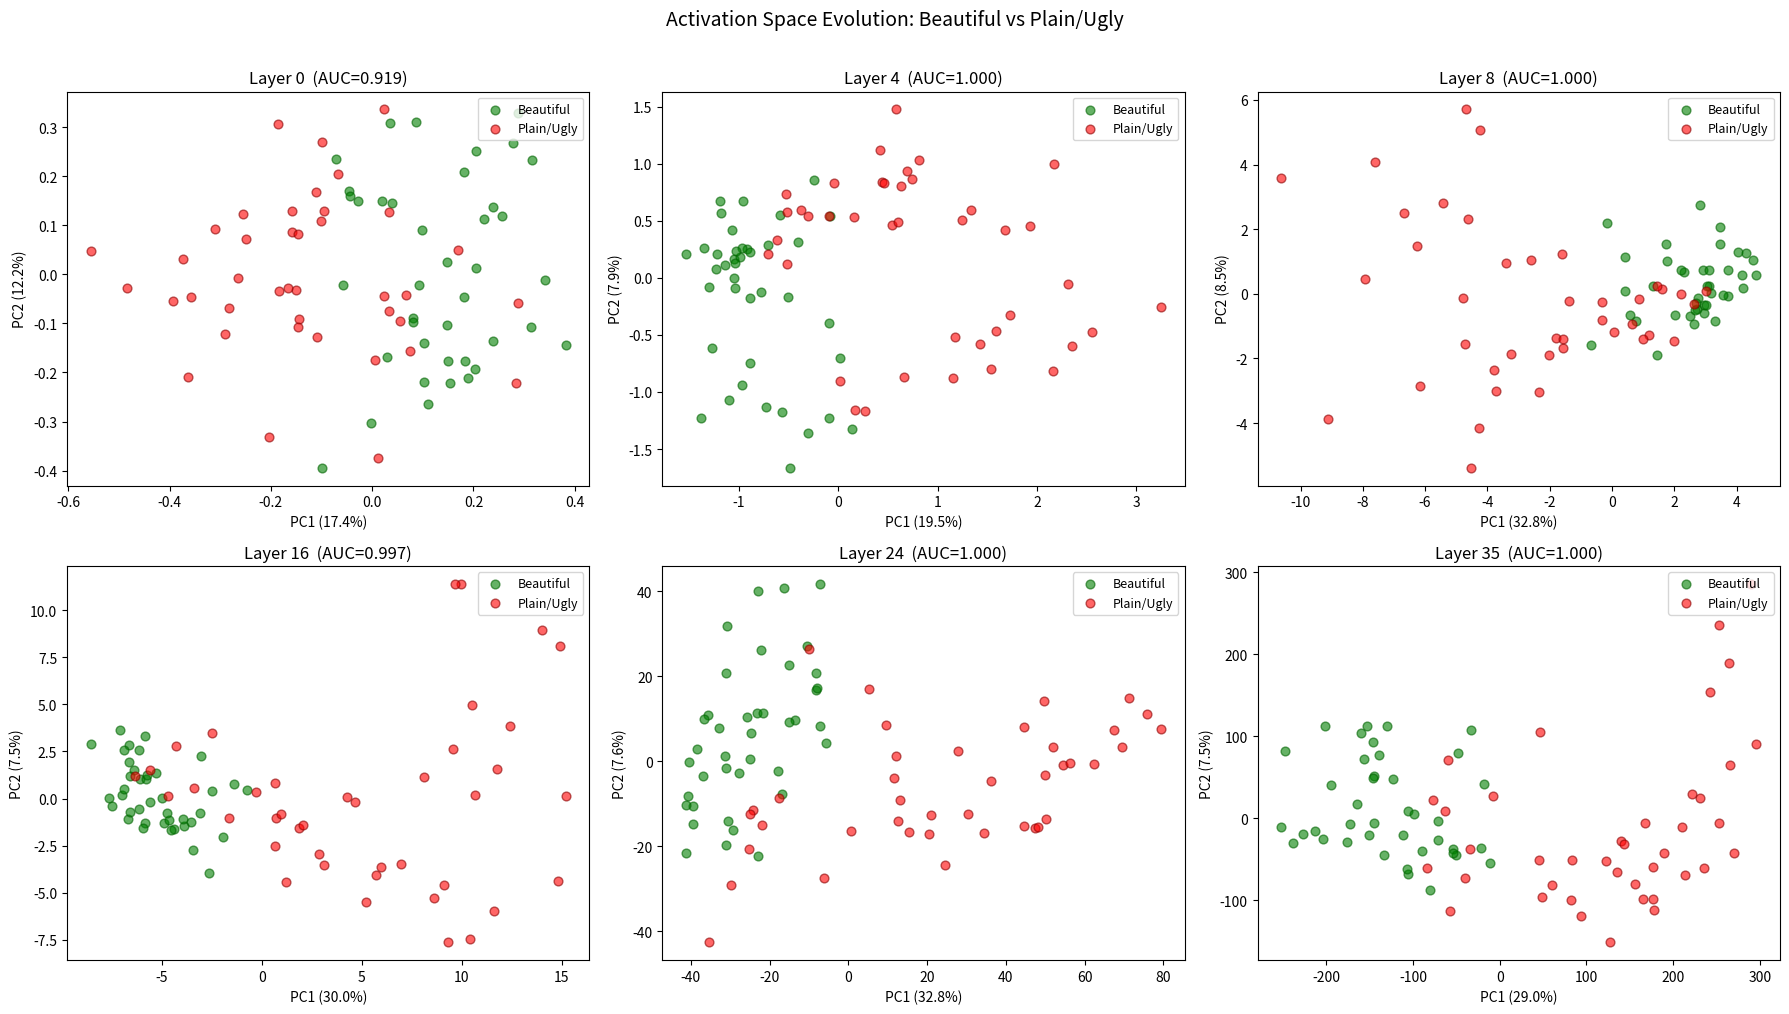

In [20]:
# Show PCA projection at 6 key layers
viz_layers = [0, 4, 8, 16, 24, 35]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, layer in enumerate(viz_layers):
    ax = axes[idx // 3, idx % 3]
    
    X = acts_content[:, layer, :]
    pca_2d = PCA(n_components=2)
    X_proj = pca_2d.fit_transform(X)
    
    # Beautiful
    ax.scatter(X_proj[:40, 0], X_proj[:40, 1], c='green', alpha=0.6, 
               label='Beautiful', s=40, edgecolors='darkgreen')
    # Ugly
    ax.scatter(X_proj[40:, 0], X_proj[40:, 1], c='red', alpha=0.6,
               label='Plain/Ugly', s=40, edgecolors='darkred')
    
    ax.set_title(f'Layer {layer}  (AUC={probe_content[layer, 0]:.3f})', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')

plt.suptitle('Activation Space Evolution: Beautiful vs Plain/Ugly', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'activation_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary & Save Results

In [21]:
# --- Save all analysis results ---
np.savez_compressed(OUTPUT_DIR / 'emergence_analysis_results.npz',
    probe_content=probe_content,
    probe_judgment=probe_judgment,
    gradient_content=gradient_content,
    gradient_judgment=gradient_judgment,
    entropy_beautiful=entropy_beautiful,
    entropy_ugly=entropy_ugly,
    entropy_diff=entropy_diff,
    js_divergence=js_divergence,
    analysis_layers=np.array(ANALYSIS_LAYERS),
    labels=LABELS,
)

# Print experiment summary
print('=' * 60)
print('EXPERIMENT 3 SUMMARY: Layer-by-Layer Aesthetic Emergence')
print('=' * 60)
print(f'Model: Qwen3-8B Q4_K_M ({N_LAYERS} layers, {N_EMBD} hidden dim, {N_HEADS} heads)')
print(f'Dataset: {len(ALL_SENTENCES)} sentences (40 beautiful + 40 plain/ugly)')

print(f'\n--- Content Probing (raw sentence) ---')
for th in [0.75, 0.90, 0.95, 0.99]:
    exceed = np.where(probe_content[:, 0] >= th - 0.001)[0]
    print(f'  AUC ≥ {th:.2f}: layer {exceed[0] if len(exceed) > 0 else "never"}')
best_c = np.argmax(probe_content[:, 0])
print(f'  Peak: layer {best_c} (AUC = {probe_content[best_c, 0]:.3f})')

print(f'\n--- Judgment Probing ("Is this beautiful?") ---')
for th in [0.75, 0.90, 0.95, 0.99]:
    exceed = np.where(probe_judgment[:, 0] >= th - 0.001)[0]
    print(f'  AUC ≥ {th:.2f}: layer {exceed[0] if len(exceed) > 0 else "never"}')
best_j = np.argmax(probe_judgment[:, 0])
print(f'  Peak: layer {best_j} (AUC = {probe_judgment[best_j, 0]:.3f})')

print(f'\n--- Peak Information Gain Layers ---')
print(f'  Content:  {np.argsort(gradient_content)[-3:][::-1]}')
print(f'  Judgment: {np.argsort(gradient_judgment)[-3:][::-1]}')

print(f'\n--- Top Aesthetic Attention Heads (JS Divergence) ---')
flat_js = js_divergence.flatten()
for idx in np.argsort(flat_js)[-5:][::-1]:
    li, head = divmod(idx, N_HEADS)
    layer = ANALYSIS_LAYERS[li]
    print(f'  Layer {layer}, Head {head}: JS = {js_divergence[li, head]:.4f}')

print(f'\nResults saved to: {OUTPUT_DIR}')
print('=' * 60)

EXPERIMENT 3 SUMMARY: Layer-by-Layer Aesthetic Emergence
Model: Qwen3-8B Q4_K_M (36 layers, 4096 hidden dim, 32 heads)
Dataset: 80 sentences (40 beautiful + 40 plain/ugly)

--- Content Probing (raw sentence) ---
  AUC ≥ 0.75: layer 0
  AUC ≥ 0.90: layer 0
  AUC ≥ 0.95: layer 1
  AUC ≥ 0.99: layer 3
  Peak: layer 3 (AUC = 1.000)

--- Judgment Probing ("Is this beautiful?") ---
  AUC ≥ 0.75: layer 0
  AUC ≥ 0.90: layer 3
  AUC ≥ 0.95: layer 6
  AUC ≥ 0.99: layer 12
  Peak: layer 18 (AUC = 1.000)

--- Peak Information Gain Layers ---
  Content:  [0 3 2]
  Judgment: [3 2 6]

--- Top Aesthetic Attention Heads (JS Divergence) ---
  Layer 28, Head 0: JS = 0.6948
  Layer 24, Head 8: JS = 0.6169
  Layer 24, Head 29: JS = 0.4910
  Layer 28, Head 23: JS = 0.4410
  Layer 32, Head 11: JS = 0.4219

Results saved to: /workspace/Data/aesthetic_emergence


In [22]:
# Cleanup
engine.reset()
print('Engine reset. Ready for next experiment.')

Engine reset. Ready for next experiment.
